In [39]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor, VotingRegressor
from sklearn.model_selection import train_test_split
import xgboost as xgb
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt

In [40]:
df = pd.read_csv("best_data.csv")

In [41]:
df = df[df.Percent_Bleaching > 1]

In [42]:
df.shape

(9840, 51)

# PCA

In [43]:
X = df.drop("Percent_Bleaching", axis=1)
Y = df["Percent_Bleaching"]

In [44]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [45]:
X_train_raw_month, X_test_raw_month = X_train_raw[['Month_1', 'Month_2', 'Month_3', 'Month_4', 'Month_5', 'Month_6',
       'Month_7', 'Month_8', 'Month_9', 'Month_10', 'Month_11', 'Month_12']].copy(), X_test_raw[['Month_1', 'Month_2', 'Month_3', 'Month_4', 'Month_5', 'Month_6',
       'Month_7', 'Month_8', 'Month_9', 'Month_10', 'Month_11', 'Month_12']].copy()

X_train_raw_fe, X_test_fe = X_train_raw[['Latitude_Degrees', 'Longitude_Degrees', 'Depth_m', 'ClimSST', 'SSTA']].copy(), \
       X_test_raw[['Latitude_Degrees', 'Longitude_Degrees', 'Depth_m', 'ClimSST', 'SSTA']].copy()


X_train_raw = X_train_raw.drop(columns= ['Month_1', 'Month_2', 'Month_3', 'Month_4', 'Month_5', 'Month_6',
       'Month_7', 'Month_8', 'Month_9', 'Month_10', 'Month_11', 'Month_12'])
X_test_raw = X_test_raw.drop(columns= ['Month_1', 'Month_2', 'Month_3', 'Month_4', 'Month_5', 'Month_6',
       'Month_7', 'Month_8', 'Month_9', 'Month_10', 'Month_11', 'Month_12'])

In [46]:
imputer = SimpleImputer(strategy='median')
X_train_imp = imputer.fit_transform(X_train_raw)
X_test_imp = imputer.transform(X_test_raw)

# SEPARATE imputer for FE — and keep as DataFrame
fe_imputer = SimpleImputer(strategy='median')
X_train_raw_fe = pd.DataFrame(
    fe_imputer.fit_transform(X_train_raw_fe),
    columns=X_train_raw_fe.columns,
    index=X_train_raw_fe.index
)
X_test_fe = pd.DataFrame(
    fe_imputer.transform(X_test_fe),
    columns=X_test_fe.columns,
    index=X_test_fe.index
)

scaler = StandardScaler()
X_train_ss = scaler.fit_transform(X_train_imp)
X_test_ss = scaler.transform(X_test_imp)

In [47]:
pca = PCA(n_components=0.75)
X_train_pca = pca.fit_transform(X_train_ss)
X_test_pca = pca.transform(X_test_ss)

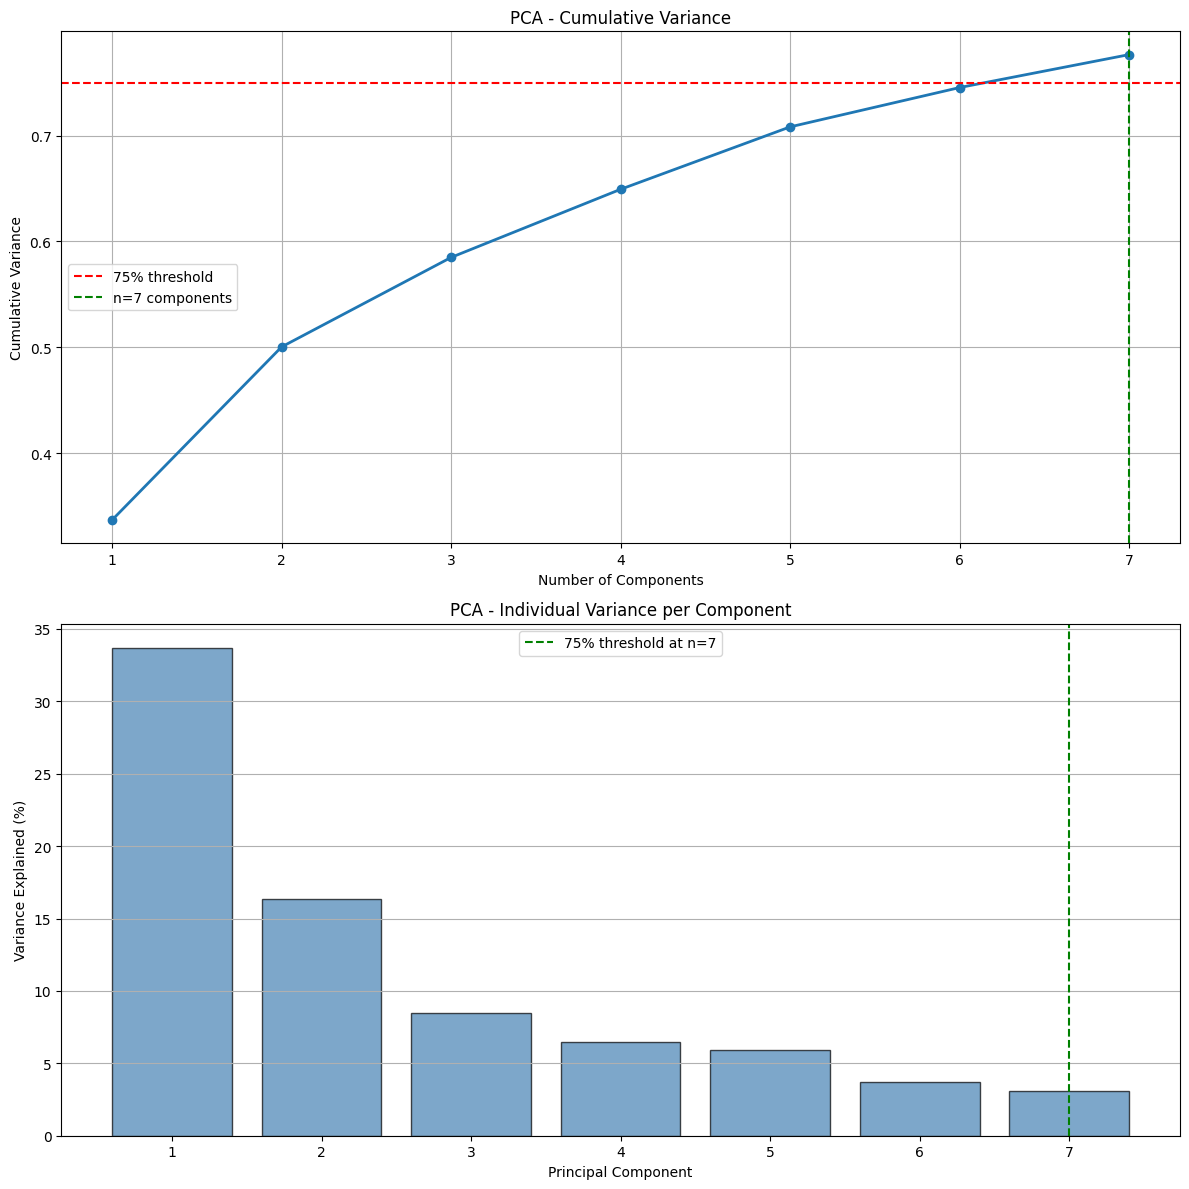

✅ Components needed for 75% variance: 7
✅ Variance explained by 7 components: 0.7767


In [48]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 12))

# --- Plot 1: Cumulative Variance (your existing plot) ---
cumvar = np.cumsum(pca.explained_variance_ratio_)
n_components_75 = np.argmax(cumvar >= 0.75) + 1

ax1.plot(range(1, len(cumvar)+1), cumvar, marker='o', linewidth=2)
ax1.axhline(y=0.75, color='r', linestyle='--', label='75% threshold')
ax1.axvline(x=n_components_75, color='g', linestyle='--', 
            label=f'n={n_components_75} components')
ax1.set_xlabel('Number of Components')
ax1.set_ylabel('Cumulative Variance')
ax1.set_title('PCA - Cumulative Variance')
ax1.legend()
ax1.grid(True)

# --- Plot 2: Individual variance per component (bar chart) ---
ax2.bar(range(1, len(pca.explained_variance_ratio_)+1), 
        pca.explained_variance_ratio_ * 100,
        color='steelblue', alpha=0.7, edgecolor='black')
ax2.axvline(x=n_components_75, color='g', linestyle='--',
            label=f'75% threshold at n={n_components_75}')
ax2.set_xlabel('Principal Component')
ax2.set_ylabel('Variance Explained (%)')
ax2.set_title('PCA - Individual Variance per Component')
ax2.legend()
ax2.grid(True, axis='y')

plt.tight_layout()
plt.savefig('pca_variance.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✅ Components needed for 75% variance: {n_components_75}")
print(f"✅ Variance explained by {n_components_75} components: {cumvar[n_components_75-1]:.4f}")

In [49]:
X_train_pca_df = pd.DataFrame(X_train_pca, columns=[f'PC{i+1}' for i in range(X_train_pca.shape[1])])
X_test_pca_df = pd.DataFrame(X_test_pca, columns=[f'PC{i+1}' for i in range(X_test_pca.shape[1])])

X_train_raw_month = X_train_raw_month.reset_index(drop=True)
X_test_raw_month = X_test_raw_month.reset_index(drop=True)

X_train_raw_fe = X_train_raw_fe.reset_index(drop=True)
X_test_fe = X_test_fe.reset_index(drop=True)

X_train_pca = pd.concat([X_train_pca_df, X_train_raw_month, X_train_raw_fe], axis=1)
X_test_pca  = pd.concat([X_test_pca_df,  X_test_raw_month,  X_test_fe],       axis=1)

# LazyPred

In [50]:
from lazypredict.Supervised import LazyRegressor
from sklearn.model_selection import train_test_split

In [54]:
reg = LazyRegressor(verbose=0, ignore_warnings=True, custom_metric=None)
models, predictions = reg.fit(X_train_pca, X_test_pca, y_train, y_test)

print(models)

                               Adjusted R-Squared     R-Squared         RMSE  \
Model                                                                          
ExtraTreesRegressor                      0.614071      0.618780    16.505794   
RandomForestRegressor                    0.595112      0.600052    16.906364   
XGBRegressor                             0.550174      0.555663    17.819887   
BaggingRegressor                         0.538643      0.544273    18.046838   
HistGradientBoostingRegressor            0.510524      0.516497    18.588669   
KNeighborsRegressor                      0.450633      0.457336    19.693097   
ExtraTreeRegressor                       0.362662      0.370438    21.211319   
GradientBoostingRegressor                0.357895      0.365730    21.290494   
MLPRegressor                             0.332331      0.340477    21.710183   
DecisionTreeRegressor                    0.242842      0.252080    23.119372   
TransformedTargetRegressor              

In [65]:
import optuna
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.model_selection import cross_val_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import ExtraTreesRegressor, HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.metrics import mean_absolute_error

# OpTuna

In [53]:
# ── prepare a version of X_train that already has month columns ──
month_cols = ['Month_1','Month_2','Month_3','Month_4','Month_5','Month_6',
              'Month_7','Month_8','Month_9','Month_10','Month_11','Month_12',
              'Latitude_Degrees', 'Longitude_Degrees', 'Depth_m', 'ClimSST', 'SSTA']

X_train_no_month = X_train_raw.copy() 
X_train_month = pd.concat([
    X_train_raw_month.reset_index(drop=True),
    X_train_raw_fe.reset_index(drop=True)
], axis=1)

# helper: run CV with month columns reattached after PCA inside each fold
def cv_with_month(pipeline, X_num, X_mon, y, cv=4):
    from sklearn.model_selection import KFold

    # Reset all indices upfront so iloc slicing stays aligned
    X_num = X_num.reset_index(drop=True)
    X_mon = X_mon.reset_index(drop=True)
    y     = y.reset_index(drop=True)

    kf = KFold(n_splits=cv, shuffle=True, random_state=42)
    scores = []
    for train_idx, val_idx in kf.split(X_num):
        X_num_tr, X_num_val = X_num.iloc[train_idx], X_num.iloc[val_idx]
        X_mon_tr  = X_mon.iloc[train_idx].reset_index(drop=True)
        X_mon_val = X_mon.iloc[val_idx].reset_index(drop=True)
        y_tr  = y.iloc[train_idx].reset_index(drop=True)
        y_val = y.iloc[val_idx].reset_index(drop=True)

        # fit the pipeline (impute+scale+pca) on numeric only
        steps_no_model = Pipeline(pipeline.steps[:-1])
        X_tr_pca  = steps_no_model.fit_transform(X_num_tr)
        X_val_pca = steps_no_model.transform(X_num_val)

        n_pcs = X_tr_pca.shape[1]
        pc_cols = [f'PC{i+1}' for i in range(n_pcs)]

        X_tr_final  = pd.concat([pd.DataFrame(X_tr_pca,  columns=pc_cols), X_mon_tr],  axis=1)
        X_val_final = pd.concat([pd.DataFrame(X_val_pca, columns=pc_cols), X_mon_val], axis=1)

        model = pipeline.steps[-1][1]
        model.fit(X_tr_final, y_tr)
        scores.append(model.score(X_val_final, y_val))   # R²
    return np.mean(scores)

In [55]:
def et_objective(trial):
    model = ExtraTreesRegressor(
        n_estimators     = trial.suggest_int("n_estimators", 50, 300),
        max_depth        = trial.suggest_int("max_depth", 5, 40),
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 5),
        max_features     = trial.suggest_categorical("max_features", ["sqrt", "log2"]),
        n_jobs=-1, random_state=42
    )
    pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler()),
        ('pca',     PCA(n_components=0.75)),
        ('model',   model)
    ])
    return cv_with_month(pipeline, X_train_no_month, X_train_month, y_train)

et_study = optuna.create_study(direction="maximize")
et_study.optimize(et_objective, n_trials=50)
print("========== ET BEST ==========")
print(et_study.best_params)
print(f"Best R²: {et_study.best_value:.4f}")

[I 2026-05-08 11:31:04,331] A new study created in memory with name: no-name-3b641972-f60e-44c1-a6fe-34facf3c5e00
[I 2026-05-08 11:31:05,214] Trial 0 finished with value: 0.4193437555080193 and parameters: {'n_estimators': 221, 'max_depth': 36, 'min_samples_leaf': 3, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.4193437555080193.
[I 2026-05-08 11:31:06,144] Trial 1 finished with value: 0.30869258929497134 and parameters: {'n_estimators': 273, 'max_depth': 16, 'min_samples_leaf': 5, 'max_features': 'log2'}. Best is trial 0 with value: 0.4193437555080193.
[I 2026-05-08 11:31:07,110] Trial 2 finished with value: 0.3510162858287301 and parameters: {'n_estimators': 290, 'max_depth': 14, 'min_samples_leaf': 2, 'max_features': 'log2'}. Best is trial 0 with value: 0.4193437555080193.
[I 2026-05-08 11:31:07,482] Trial 3 finished with value: 0.17800327269278968 and parameters: {'n_estimators': 75, 'max_depth': 8, 'min_samples_leaf': 2, 'max_features': 'sqrt'}. Best is trial 0 with value

========== ET BEST ==========
{'n_estimators': 146, 'max_depth': 27, 'min_samples_leaf': 1, 'max_features': 'sqrt'}
Best R²: 0.5425


In [56]:
def rf_objective(trial):
    model = RandomForestRegressor(
        n_estimators      = trial.suggest_int("n_estimators", 50, 300),
        max_depth         = trial.suggest_int("max_depth", 5, 40),
        min_samples_split = trial.suggest_int("min_samples_split", 2, 10),
        min_samples_leaf  = trial.suggest_int("min_samples_leaf", 1, 5),
        max_features      = trial.suggest_categorical("max_features", ["sqrt", "log2"]),
        n_jobs=-1, random_state=42
    )
    pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler()),
        ('pca',     PCA(n_components=0.75)),
        ('model',   model)
    ])
    return cv_with_month(pipeline, X_train_no_month, X_train_month, y_train)

rf_study = optuna.create_study(direction="maximize")
rf_study.optimize(rf_objective, n_trials=50)
print("========== RF BEST ==========")
print(rf_study.best_params)
print(f"Best R²: {rf_study.best_value:.4f}")

[I 2026-05-08 11:31:50,073] A new study created in memory with name: no-name-25b71ff6-5cb3-41dd-86c5-521fae4cb5a4
[I 2026-05-08 11:31:51,548] Trial 0 finished with value: 0.46672249806083366 and parameters: {'n_estimators': 217, 'max_depth': 27, 'min_samples_split': 4, 'min_samples_leaf': 5, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.46672249806083366.
[I 2026-05-08 11:31:52,636] Trial 1 finished with value: 0.31774916424555166 and parameters: {'n_estimators': 187, 'max_depth': 7, 'min_samples_split': 6, 'min_samples_leaf': 3, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.46672249806083366.
[I 2026-05-08 11:31:53,477] Trial 2 finished with value: 0.4918569239337105 and parameters: {'n_estimators': 86, 'max_depth': 22, 'min_samples_split': 2, 'min_samples_leaf': 3, 'max_features': 'log2'}. Best is trial 2 with value: 0.4918569239337105.
[I 2026-05-08 11:31:54,394] Trial 3 finished with value: 0.46521033038663806 and parameters: {'n_estimators': 116, 'max_depth': 27,

========== RF BEST ==========
{'n_estimators': 197, 'max_depth': 26, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt'}
Best R²: 0.5355


In [63]:
def hgb_objective(trial):
    model = HistGradientBoostingRegressor(
        max_iter          = trial.suggest_int  ("max_iter",          50, 400),
        max_depth         = trial.suggest_int  ("max_depth",          3,  15),
        learning_rate     = trial.suggest_float("learning_rate",  0.005, 0.1),
        min_samples_leaf  = trial.suggest_int  ("min_samples_leaf",   1,  50),
        l2_regularization = trial.suggest_float("l2_regularization", 0.0, 1.0),
        random_state=42
    )
    pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler()),
        ('pca',     PCA(n_components=0.75)),
        ('model',   model)
    ])
    return cv_with_month(pipeline, X_train_no_month, X_train_month, y_train)

hgb_study = optuna.create_study(direction="maximize")
hgb_study.optimize(hgb_objective, n_trials=50)
print("========== HGB BEST ==========")
print(hgb_study.best_params)
print(f"Best R²: {hgb_study.best_value:.4f}")

[I 2026-05-08 11:58:33,263] A new study created in memory with name: no-name-9c0dccd3-5869-49f8-9e12-0fe149be980b
[I 2026-05-08 11:58:35,037] Trial 0 finished with value: 0.3402901930784278 and parameters: {'max_iter': 196, 'max_depth': 15, 'learning_rate': 0.011194666715201591, 'min_samples_leaf': 48, 'l2_regularization': 0.7419615241544795}. Best is trial 0 with value: 0.3402901930784278.
[I 2026-05-08 11:58:35,910] Trial 1 finished with value: 0.24935689359013719 and parameters: {'max_iter': 296, 'max_depth': 3, 'learning_rate': 0.010985654196187624, 'min_samples_leaf': 43, 'l2_regularization': 0.826531392491519}. Best is trial 0 with value: 0.3402901930784278.
[I 2026-05-08 11:58:36,676] Trial 2 finished with value: 0.3416016420794712 and parameters: {'max_iter': 268, 'max_depth': 3, 'learning_rate': 0.040631573559112545, 'min_samples_leaf': 20, 'l2_regularization': 0.8616064366595196}. Best is trial 2 with value: 0.3416016420794712.
[I 2026-05-08 11:58:38,485] Trial 3 finished wit

========== HGB BEST ==========
{'max_iter': 400, 'max_depth': 14, 'learning_rate': 0.09675297292797276, 'min_samples_leaf': 11, 'l2_regularization': 0.010264285754308516}
Best R²: 0.5355


# Start

In [ ]:
# ========== ET BEST ==========
# {'n_estimators': 146, 'max_depth': 27, 'min_samples_leaf': 1, 'max_features': 'sqrt'}

# ========== RF BEST ==========
# {'n_estimators': 197, 'max_depth': 26, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt'}

# ========== HGB BEST ==========
# {'max_iter': 400, 'max_depth': 14, 'learning_rate': 0.09675297292797276, 'min_samples_leaf': 11, 'l2_regularization': 0.010264285754308516}


In [68]:
hgb_model = HistGradientBoostingRegressor(
    **hgb_study.best_params,
    random_state=42
)

et_model = ExtraTreesRegressor(
    **et_study.best_params,
    n_jobs=-1,
    random_state=42
)

rf_model = RandomForestRegressor(
    **rf_study.best_params,
    n_jobs=-1, 
    random_state=42
)

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold
from sklearn.base import clone
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.ensemble import (
    RandomForestClassifier, ExtraTreesClassifier, BaggingClassifier, VotingClassifier,
    RandomForestRegressor, ExtraTreesRegressor, VotingRegressor, HistGradientBoostingRegressor
)
from sklearn.tree import DecisionTreeClassifier

# ============================================================
# 1. การตั้งค่าสำหรับการทำ Perturbation (Per-sample Adaptive Weighting)
# ============================================================
PERTURBATION_DICT = {
    'ClimSST':           0.5,
    'SSTA':              0.05,
    'Depth_m':           1.0,
    'Longitude_Degrees': 0.001,
    'Latitude_Degrees':  0.001,
}
PERTURB_FEATURES = ['Latitude_Degrees', 'Longitude_Degrees', 'Depth_m', 'ClimSST', 'SSTA']

def perturb_feature_batch(X, feature, delta):
    X_p, X_n = X.copy(), X.copy()
    X_p[feature] = X[feature] + delta
    X_n[feature] = X[feature] - delta
    if feature == 'Depth_m':
        X_p[feature], X_n[feature] = X_p[feature].clip(lower=0), X_n[feature].clip(lower=0)
    elif feature == 'Latitude_Degrees':
        X_p[feature], X_n[feature] = X_p[feature].clip(-90, 90), X_n[feature].clip(-90, 90)
    elif feature == 'ClimSST':
        X_p[feature], X_n[feature] = X_p[feature].clip(lower=0), X_n[feature].clip(lower=0)
    return X_p, X_n

class PerturbationAwareEnsemble:
    def __init__(self, models, perturbation_dict, features):
        self.models = models
        self.perturbation_dict = perturbation_dict
        self.features = features
    
    def fit(self, X, y):
        for m in self.models: 
            m.fit(X, y)
        return self
    
    def predict(self, X):
        n_samples, n_models = len(X), len(self.models)
        base_preds = np.array([m.predict(X) for m in self.models])
        total_errors = np.zeros((n_models, n_samples))
        for feature in self.features:
            if feature in X.columns:
                delta = self.perturbation_dict[feature]
                X_p, X_n = perturb_feature_batch(X, feature, delta)
                for i, model in enumerate(self.models):
                    total_errors[i] += np.abs(model.predict(X_p) - base_preds[i])
                    total_errors[i] += np.abs(model.predict(X_n) - base_preds[i])
        inverse = 1.0 / (total_errors + 1e-10)
        weights = inverse / inverse.sum(axis=0)
        return (weights * base_preds).sum(axis=0)

# ============================================================
# 2. เตรียม Hyperparameters (จาก Optuna Studies)
# ============================================================
# Classification Params
clf_rf_params = {'n_estimators': 500, 'max_depth': 45, 'min_samples_split': 3, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'random_state': 42, 'n_jobs': -1}
clf_et_params = {'n_estimators': 423, 'max_depth': 23, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': None, 'random_state': 42, 'n_jobs': -1}

# จัดการพารามิเตอร์ Bagging (แยกส่วน Tree ออกจาก Bagging Wrapper)
bg_tree_depth = 20
bg_tree_leaf = 1
clf_bg_params_cleaned = {'n_estimators': 90, 'max_samples': 0.9869618111006297, 'max_features': 0.6939338393935504, 'bootstrap': False, 'random_state': 42, 'n_jobs': -1}

# Regression Params
reg_et_params = {'n_estimators': 146, 'max_depth': 27, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'random_state': 42, 'n_jobs': -1}
reg_rf_params = {'n_estimators': 197, 'max_depth': 26, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'random_state': 42, 'n_jobs': -1}
reg_hgb_params = {'max_iter': 400, 'max_depth': 14, 'learning_rate': 0.09675297292797276, 'min_samples_leaf': 11, 'l2_regularization': 0.010264285754308516, 'random_state': 42}

# ============================================================
# 3. เริ่มต้น K-Fold Cross Validation (k=4)
# ============================================================
df_full = pd.read_csv("best_data.csv")
df_full['Status'] = (df_full['Percent_Bleaching'] <= 1).astype(bool)

X_all = df_full.drop(columns=['Percent_Bleaching', 'Status'])
y_class = df_full['Status']
y_reg = df_full['Percent_Bleaching']

month_cols = [f'Month_{i}' for i in range(1, 13)]
n_splits = 4
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

model_names = ['ExtraTrees', 'RandomForest', 'HistGradientBoost', 'Standard Voting', 'Perturbation-Aware']
all_results = {name: [] for name in model_names}

print("="*85)
print(f"Two-Stage K-Fold Cross Validation (k={n_splits})")
print("="*85)

for fold, (train_idx, test_idx) in enumerate(kf.split(X_all), 1):
    X_tr_raw, X_te_raw = X_all.iloc[train_idx], X_all.iloc[test_idx]
    y_cl_tr, y_cl_te = y_class.iloc[train_idx], y_class.iloc[test_idx]
    y_rg_tr, y_rg_te = y_reg.iloc[train_idx], y_reg.iloc[test_idx]

    # --- Preprocessing ภายใน Fold ---
    X_num_tr = X_tr_raw.drop(columns=month_cols)
    imputer = SimpleImputer(strategy='median').fit(X_num_tr)
    scaler = StandardScaler().fit(imputer.transform(X_num_tr))
    pca = PCA(n_components=0.75).fit(scaler.transform(imputer.transform(X_num_tr)))
    
    def transform_data(raw_df):
        num_part = raw_df.drop(columns=month_cols)
        pca_res = pca.transform(scaler.transform(imputer.transform(num_part)))
        df_pca = pd.DataFrame(pca_res, columns=[f'PC{i+1}' for i in range(pca_res.shape[1])], index=raw_df.index)
        return pd.concat([df_pca, raw_df[month_cols], raw_df[PERTURB_FEATURES]], axis=1)

    X_tr_final = transform_data(X_tr_raw)
    X_te_final = transform_data(X_te_raw)

    # --- STAGE 1: Classifier (Box 1) ---
    bg_tree = DecisionTreeClassifier(max_depth=bg_tree_depth, min_samples_leaf=bg_tree_leaf, random_state=42)
    clf = VotingClassifier(estimators=[
        ('rf', RandomForestClassifier(**clf_rf_params)),
        ('et', ExtraTreesClassifier(**clf_et_params)),
        ('bg', BaggingClassifier(estimator=bg_tree, **clf_bg_params_cleaned))
    ], voting='soft').fit(X_tr_final, y_cl_tr)
    
    pred_low_bleaching = clf.predict(X_te_final) # True คือ <= 1% ให้ตอบ 0

    # --- STAGE 2: Various Regressors (Box 2) ---
    X_rg_tr_filtered = X_tr_final[y_rg_tr > 1]
    y_rg_tr_filtered = y_rg_tr[y_rg_tr > 1]
    
    reg_candidates = {
        'ExtraTrees': ExtraTreesRegressor(**reg_et_params),
        'RandomForest': RandomForestRegressor(**reg_rf_params),
        'HistGradientBoost': HistGradientBoostingRegressor(**reg_hgb_params),
        'Standard Voting': VotingRegressor([
            ('et', ExtraTreesRegressor(**reg_et_params)),
            ('rf', RandomForestRegressor(**reg_rf_params)),
            ('hgb', HistGradientBoostingRegressor(**reg_hgb_params))
        ]),
        'Perturbation-Aware': PerturbationAwareEnsemble(
            models=[
                ExtraTreesRegressor(**reg_et_params), 
                RandomForestRegressor(**reg_rf_params), 
                HistGradientBoostingRegressor(**reg_hgb_params)
            ],
            perturbation_dict=PERTURBATION_DICT, features=PERTURB_FEATURES
        )
    }

    for name, model in reg_candidates.items():
        model.fit(X_rg_tr_filtered, y_rg_tr_filtered)
        
        # กลไก Two-stage: ถ้า Stage 1 ทายว่าต่ำ (True) -> 0, ถ้าสูง (False) -> ใช้ Regressor
        final_preds = np.zeros(len(X_te_final))
        to_reg_mask = ~pred_low_bleaching
        
        if to_reg_mask.any():
            final_preds[to_reg_mask] = model.predict(X_te_final[to_reg_mask])
            
        all_results[name].append({
            'R2': r2_score(y_rg_te, final_preds),
            'RMSE': np.sqrt(mean_squared_error(y_rg_te, final_preds)),
            'MAE': mean_absolute_error(y_rg_te, final_preds)
        })
    print(f"Done Fold {fold}/4")

# ============================================================
# 4. แสดงผลลัพธ์การเปรียบเทียบประสิทธิภาพ
# ============================================================
print("\n" + "="*85)
print(f"{'Final Two-Stage Model Comparison':<25} | {'Mean R2':>8} | {'Mean RMSE':>8} | {'Mean MAE':>8}")
print("-" * 85)

for name in model_names:
    res_df = pd.DataFrame(all_results[name])
    m = res_df.mean()
    print(f"{name:<32} | {m['R2']:>8.4f} | {m['RMSE']:>9.4f} | {m['MAE']:>8.4f}")
print("="*85)

BASELINE RESULTS (single seed = 42)
Model                         R²        RMSE       MAE      Acc%
-----------------------------------------------------------------
HistGradientBoost         0.5838     17.2458   11.6825     88.32
ExtraTrees                0.6161     16.5647   10.3792     89.62
RandomForest              0.6157     16.5725   11.3315     88.67
Voting (Ensemble)         0.6237     16.3980   10.9555     89.04
-----------------------------------------------------------------
Paper baseline:           0.2500      7.9100         —     96.00


# K-Fold

In [ ]:
from sklearn.model_selection import KFold
from sklearn.base import clone

n_splits = 4
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

# Categorical/extra columns (จะ append ทีหลัง — ไม่ผ่าน PCA)
month_cols = ['Month_1','Month_2','Month_3','Month_4','Month_5','Month_6',
              'Month_7','Month_8','Month_9','Month_10','Month_11','Month_12']
paper_features = ['Latitude_Degrees', 'Longitude_Degrees', 'Depth_m', 'ClimSST', 'SSTA']

# X_extra = month + paper (จะเพิ่มทีหลัง)
X_month = X[month_cols].copy()
X_paper = X[paper_features].copy()

# X_for_pca = ทุก features รวม paper features (จะผ่าน PCA)
# แต่ตัด month ออก (เพราะ month เป็น categorical ไม่ควรเข้า PCA)
X_for_pca = X.drop(columns=month_cols)

cv_models = {
    'ExtraTrees':           et_model,
    'RandomForest':         rf_model,
    'HistGradientBoost':    hgb_model,
    'Voting (Ensemble)':    VotingRegressor([
        ('et',  et_model),
        ('rf',  rf_model),
        ('hgb', hgb_model)
    ])
}

print("=" * 70)
print("K-Fold Cross Validation Summary (k=4)")
print("=" * 70)
print(f"{'Model':<22}{'Mean R²':>14}{'Mean RMSE':>14}{'Mean MAE':>14}")
print("-" * 70)

for name, base_model in cv_models.items():
    r2_scores, rmse_scores, mae_scores = [], [], []

    for train_idx, test_idx in kf.split(X_for_pca):
        # Split numeric (for PCA), month, and paper separately
        X_fold_train, X_fold_test = X_for_pca.iloc[train_idx], X_for_pca.iloc[test_idx]
        month_fold_train = X_month.iloc[train_idx].reset_index(drop=True)
        month_fold_test  = X_month.iloc[test_idx].reset_index(drop=True)
        paper_fold_train = X_paper.iloc[train_idx].copy()
        paper_fold_test  = X_paper.iloc[test_idx].copy()
        y_fold_train     = Y.iloc[train_idx].reset_index(drop=True)
        y_fold_test      = Y.iloc[test_idx].reset_index(drop=True)

        # Impute → Scale → PCA (numeric only — รวม paper features ใน X_fold_train)
        imputer     = SimpleImputer(strategy='median')
        X_train_imp = imputer.fit_transform(X_fold_train)
        X_test_imp  = imputer.transform(X_fold_test)

        # ⭐ NEW: Impute paper features ที่จะ reattach (แยก imputer ตามที่ noise_robustness ทำ)
        fe_imputer = SimpleImputer(strategy='median')
        paper_fold_train = pd.DataFrame(
            fe_imputer.fit_transform(paper_fold_train),
            columns=paper_features
        ).reset_index(drop=True)
        paper_fold_test = pd.DataFrame(
            fe_imputer.transform(paper_fold_test),
            columns=paper_features
        ).reset_index(drop=True)

        scaler      = StandardScaler()
        X_train_ss  = scaler.fit_transform(X_train_imp)
        X_test_ss   = scaler.transform(X_test_imp)

        pca         = PCA(n_components=0.75)
        X_train_pca_fold = pca.fit_transform(X_train_ss)
        X_test_pca_fold  = pca.transform(X_test_ss)

        # Reattach: PCA + month + paper(imputed)
        n_pcs   = X_train_pca_fold.shape[1]
        pc_cols = [f'PC{i+1}' for i in range(n_pcs)]

        X_train_final = pd.concat([
            pd.DataFrame(X_train_pca_fold, columns=pc_cols),
            month_fold_train,
            paper_fold_train,
        ], axis=1)
        X_test_final  = pd.concat([
            pd.DataFrame(X_test_pca_fold, columns=pc_cols),
            month_fold_test,
            paper_fold_test,
        ], axis=1)

        # Train & evaluate
        model = clone(base_model)
        model.fit(X_train_final, y_fold_train)
        preds = model.predict(X_test_final)

        r2_scores.append(r2_score(y_fold_test, preds))
        rmse_scores.append(np.sqrt(mean_squared_error(y_fold_test, preds)))
        mae_scores.append(mean_absolute_error(y_fold_test, preds))

    print(f"{name:<22}{np.mean(r2_scores):>14.4f}{np.mean(rmse_scores):>14.4f}{np.mean(mae_scores):>14.4f}")

print("=" * 70)

K-Fold Cross Validation Summary (k=4)
Model                        Mean R²     Mean RMSE      Mean MAE
----------------------------------------------------------------------
ExtraTrees                    0.5804       17.2571       10.9119
RandomForest                  0.5667       17.5329       12.0951
HistGradientBoost             0.5541       17.7881       12.1431
Voting (Ensemble)             0.5857       17.1463       11.5222
